# Chronos-2: Applied Financial Time Series Forecasting

This notebook demonstrates the application of Amazon's zero-shot foundational time series model, **Chronos-2**, to financial market data. It covers two distinct quantitative strategies:

1. **Univariate Directional Forecasting:** A Long/Short strategy on the S&P 500 ETF (SPY) based on median expected drift.
2. **Cross-Sectional Market-Neutral Strategy:** A ranking strategy applied to S&P 500 constituents, following the Fischer & Krauss (2017) framework.

In [ ]:
%pip install 'chronos-forecasting[extras]>=2.2' 'matplotlib'

In [ ]:
import io
import requests
import numpy as np
import pandas as pd
import yfinance as yf
import torch
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mtick
from chronos import Chronos2Pipeline

# Global configuration for plots
plt.style.use('seaborn-v0_8-whitegrid')
import warnings
warnings.filterwarnings('ignore')

## Initialization
Initialize the Chronos-2 pipeline once. Using `bfloat16` significantly reduces VRAM usage without sacrificing predictive accuracy, enabling rapid backtesting.

In [ ]:
pipeline = Chronos2Pipeline.from_pretrained(
        f"amazon/chronos-2",
        device_map="cuda",
        dtype=torch.bfloat16,
    )

---
# Strategy 1: Univariate SPY Long/Short
This strategy forecasts the next-day log return of the SPY ETF using a rolling 90-day window. Trades are executed only when the median forecast ($P_{50}$) exceeds realistic transaction costs (sourced from Interactive Brokers).

In [ ]:
def fetch_and_prep_spy(start_date, end_date):
    """
    Fetches SPY data, calculates log returns, and prepares the dummy sequence for predict_df.

    Parameters
    ----------
    start_date : str
        The start date for fetching historical data in 'YYYY-MM-DD' format.
    end_date : str
        The end date for fetching historical data in 'YYYY-MM-DD' format.

    Returns
    -------
    pandas.DataFrame
        A formatted DataFrame containing SPY prices, log returns, and dummy dates.
    """
    print("Fetching SPY Data...")
    spy_raw = yf.download('SPY', start=start_date, end=end_date, auto_adjust=False)

    # Flatten yfinance 2D output
    df = spy_raw['Close'].squeeze().to_frame(name='Close')

    df['Log_Return'] = np.log(df['Close'] / df['Close'].shift(1))
    df = df.dropna().reset_index()
    df['item_id'] = 'SPY'

    # Map dates to uniform sequence to bypass predict_df weekend frequency validation
    df['Dummy_Date'] = pd.date_range(start='2000-01-01', periods=len(df), freq='D')

    return df

def run_univariate_backtest(df, pipeline, start_date, window_size=90, threshold=0.0005, cost_per_share=0.01):
    """
    Executes the rolling walk-forward backtest for the univariate strategy.

    Parameters
    ----------
    df : pandas.DataFrame
        The prepared SPY DataFrame containing historical prices and returns.
    pipeline : Chronos2Pipeline
        The initialized Chronos-2 prediction pipeline.
    start_date : str
        The start date for the backtest in 'YYYY-MM-DD' format.
    window_size : int, optional
        The number of historical days to use as context for each prediction (default is 90).
    threshold : float, optional
        The minimum predicted median log return required to trigger a trade (default is 0.0005).
    cost_per_share : float, optional
        The simulated transaction cost per share traded (default is 0.01).

    Returns
    -------
    pandas.DataFrame
        A DataFrame containing the daily predictions, signals, and calculated strategy returns.
    """
    start_idx = df.index[df['Date'] >= start_date].tolist()[0]
    predictions = []

    print("Running Univariate Walk-Forward Backtest...")
    for i in range(start_idx, len(df)):
        train_slice = df.iloc[i - window_size : i]
        input_df = train_slice[['item_id', 'Dummy_Date', 'Log_Return']]

        forecast_df = pipeline.predict_df(
            input_df,
            id_column="item_id",
            timestamp_column="Dummy_Date",
            target="Log_Return",
            prediction_length=1,
            quantile_levels=[0.5]
        )

        predictions.append({
            'Date': df['Date'].iloc[i],
            'Actual_Log_Ret': df['Log_Return'].iloc[i],
            'Actual_Price': df['Close'].iloc[i],
            'P50': forecast_df.iloc[0]['0.5']
        })

    results = pd.DataFrame(predictions)

    # Signal Generation
    results['Signal'] = np.where(results['P50'] > threshold, 1,
                        np.where(results['P50'] < -threshold, -1, 0))
    results['Long_Signal'] = np.where(results['Signal'] == 1, 1, 0)
    results['Short_Signal'] = np.where(results['Signal'] == -1, -1, 0)

    # Gross Returns
    results['Long_Log_Ret'] = results['Long_Signal'].shift(1) * results['Actual_Log_Ret']
    results['Short_Log_Ret'] = results['Short_Signal'].shift(1) * results['Actual_Log_Ret']
    results['Combined_Log_Ret'] = results['Signal'].shift(1) * results['Actual_Log_Ret']

    # Transaction Costs
    results['Cost_Pct'] = cost_per_share / results['Actual_Price']
    results['Combined_Trade_Cost'] = (results['Signal'].diff().abs() > 0) * results['Cost_Pct']

    # Net Returns
    results['Net_Long_Ret'] = np.exp(results['Long_Log_Ret']) - 1 - (results['Combined_Trade_Cost'].fillna(0) / 2)
    results['Net_Short_Ret'] = (-(np.exp(results['Short_Log_Ret']) - 1)) - (results['Combined_Trade_Cost'].fillna(0) / 2)
    results['Net_Combined_Ret'] = np.exp(results['Combined_Log_Ret']) - 1 - results['Combined_Trade_Cost'].fillna(0)

    return results

# Execute Univariate Strategy
spy_df = fetch_and_prep_spy('2023-05-01', '2026-01-01')
spy_results = run_univariate_backtest(spy_df, pipeline, start_date='2024-01-01')

Fetching SPY Data...


[*********************100%***********************]  1 of 1 completed


Running Univariate Walk-Forward Backtest...


### Univariate Strategy Evaluation
Visualizing the separated Long-Only/Short-Only performance and calculating the classification accuracy (Directional Accuracy & Hit Rate). Includes automated CSV and transparent graph exports.


=== UNIVARIATE ACCURACY METRICS ===
Raw Directional Accuracy: 55.98%
Active Trade Hit Rate:    50.66%
Total Trades Taken:       458 out of 502 days

Exported 'univariate_strategy_results.csv' and 'univariate_strategy_performance.png'


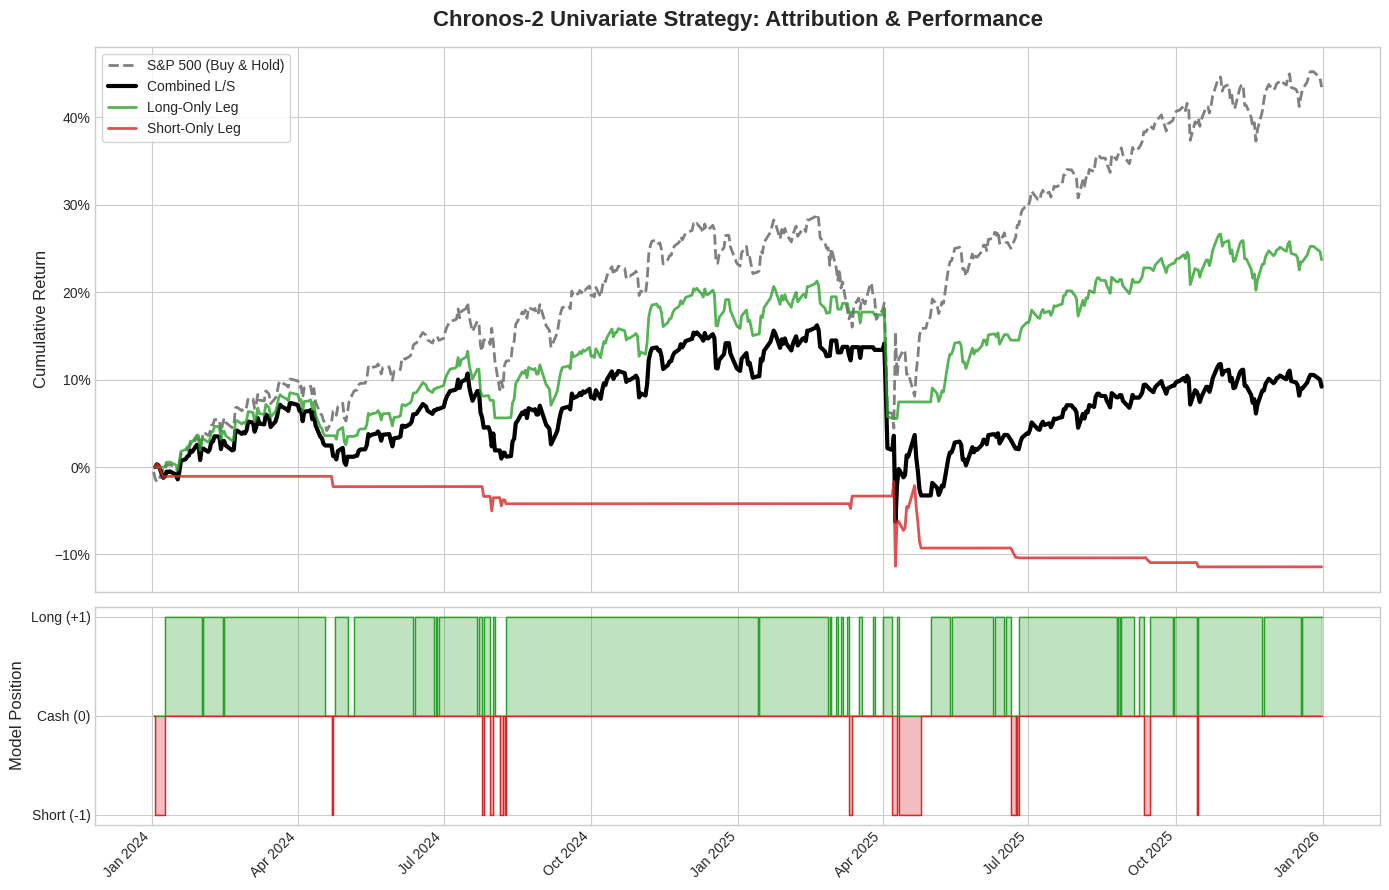

In [ ]:
def evaluate_univariate_strategy(results):
    """
    Calculates accuracy metrics, plots the univariate strategy performance, and exports results.

    Parameters
    ----------
    results : pandas.DataFrame
        The output DataFrame from the univariate backtest containing strategy returns.

    Returns
    -------
    None
    """
    # Accuracy Metrics
    correct_dir = (np.sign(results['P50']) == np.sign(results['Actual_Log_Ret'])).mean()
    active_trades = results[results['Signal'] != 0]
    hit_rate = (active_trades['Combined_Log_Ret'] > 0).mean() if len(active_trades) > 0 else 0
    total_trades_str = f"{len(active_trades)} out of {len(results)} days"

    print("\n=== UNIVARIATE ACCURACY METRICS ===")
    print(f"Raw Directional Accuracy: {correct_dir*100:.2f}%")
    print(f"Active Trade Hit Rate:    {hit_rate*100:.2f}%")
    print(f"Total Trades Taken:       {total_trades_str}")
    print("======================================\n")

    # Plotting
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), gridspec_kw={'height_ratios': [3, 1.2]}, sharex=True)
    fig.patch.set_alpha(0.0)
    ax1.patch.set_alpha(0.0)
    ax2.patch.set_alpha(0.0)

    cum_market = (1 + (np.exp(results['Actual_Log_Ret']) - 1)).cumprod() - 1
    cum_combined = (1 + results['Net_Combined_Ret']).cumprod() - 1
    cum_long = (1 + results['Net_Long_Ret']).cumprod() - 1
    cum_short = -(1 + results['Net_Short_Ret']).cumprod() + 1

    ax1.plot(results['Date'], cum_market * 100, label='S&P 500 (Buy & Hold)', color='gray', linewidth=2, linestyle='--')
    ax1.plot(results['Date'], cum_combined * 100, label='Combined L/S', color='black', linewidth=3)
    ax1.plot(results['Date'], cum_long * 100, label='Long-Only Leg', color='#2ca02c', linewidth=2, alpha=0.8)
    ax1.plot(results['Date'], cum_short * 100, label='Short-Only Leg', color='#d62728', linewidth=2, alpha=0.8)

    ax1.set_title('Chronos-2 Univariate Strategy: Attribution & Performance', fontsize=16, fontweight='bold', pad=15)
    ax1.set_ylabel('Cumulative Return', fontsize=12)
    ax1.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax1.legend(loc='upper left', frameon=True)

    # Position Panel
    ax2.plot(results['Date'], results['Long_Signal'], drawstyle='steps-post', color='#2ca02c', linewidth=1)
    ax2.fill_between(results['Date'], 0, results['Long_Signal'], color='#2ca02c', alpha=0.3, step='post', label='Long Position')
    ax2.plot(results['Date'], results['Short_Signal'], drawstyle='steps-post', color='#d62728', linewidth=1)
    ax2.fill_between(results['Date'], 0, results['Short_Signal'], color='#d62728', alpha=0.3, step='post', label='Short Position')

    ax2.set_ylabel('Model Position', fontsize=12)
    ax2.set_yticks([-1, 0, 1])
    ax2.set_yticklabels(['Short (-1)', 'Cash (0)', 'Long (+1)'])

    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')
    plt.tight_layout()

    # Export Data & Graph
    metrics_df = pd.DataFrame({
        'Metric': ['Raw Directional Accuracy', 'Active Trade Hit Rate', 'Total Trades Taken'],
        'Value': [f"{correct_dir*100:.2f}%", f"{hit_rate*100:.2f}%", total_trades_str]
    })
    metrics_df.to_csv('univariate_metrics_table.csv', index=False)
    results.to_csv('univariate_strategy_results.csv', index=False)
    plt.savefig('univariate_strategy_performance.png', transparent=True, dpi=300, bbox_inches='tight')
    print("Exported 'univariate_strategy_results.csv' and 'univariate_strategy_performance.png'")

    plt.show()

evaluate_univariate_strategy(spy_results)

---
# Strategy 2: Cross-Sectional Market-Neutral Strategy
Applying the Fischer & Krauss (2017) methodology. We predict the cross-sectional median expected drift for the S&P 500 constituents, ranking them to form a daily Long/Short portfolio (Top k / Bottom k). To eliminate survivorship bias, we dynamically fetch historical constituents using a historical S&P 500 changes CSV, ensuring we only trade the exact universe available on any given date. Missing data is forward-filled to preserve token sequence integrity.

In [ ]:
def fetch_sp500_panel(start_date, end_date):
    """
    Fetches historical S&P 500 constituents from a historical changes CSV and formats as panel data.

    Parameters
    ----------
    start_date : str
        The start date for fetching historical data in 'YYYY-MM-DD' format.
    end_date : str
        The end date for fetching historical data in 'YYYY-MM-DD' format.

    Returns
    -------
    tuple
        A tuple containing:
        - pandas.DataFrame: The melted panel data of constituent prices and returns.
        - list: A sorted list of unique dates available in the dataset.
    """
    print("Fetching Historical S&P 500 Universe from CSV...")
    # Use the raw URL for pandas to correctly parse the GitHub CSV
    csv_url = "https://raw.githubusercontent.com/fja05680/sp500/master/S%26P%20500%20Historical%20Components%20%26%20Changes(01-17-2026).csv"

    df_hist = pd.read_csv(csv_url)
    df_hist['date'] = pd.to_datetime(df_hist['date'])

    start_dt = pd.to_datetime(start_date)
    end_dt = pd.to_datetime(end_date)

    # 1. Get the latest constituents right before or on our start date
    prior_comps = df_hist[df_hist['date'] <= start_dt]
    if not prior_comps.empty:
        base_comp = prior_comps.iloc[-1]['tickers']
        base_tickers = set(str(base_comp).split(','))
    else:
        base_tickers = set()

    # 2. Get any new constituents added during our backtest window
    during_comps = df_hist[(df_hist['date'] > start_dt) & (df_hist['date'] <= end_dt)]
    during_tickers = set()
    for t_list in during_comps['tickers']:
        during_tickers.update(str(t_list).split(','))

    all_tickers = base_tickers.union(during_tickers)

    # Clean tickers for yfinance (e.g., BRK.B -> BRK-B)
    tickers = [t.strip().replace('.', '-') for t in all_tickers if pd.notna(t) and t.strip()]
    tickers = list(set(tickers))

    print(f"Identified {len(tickers)} unique historical tickers for the period. Downloading Data...")
    data = yf.download(tickers, start=start_date, end=end_date, auto_adjust=False)

    # Forward Fill to patch Yahoo data holes, drop failed downloads
    prices = data['Close'].ffill().dropna(axis=1, how='all')

    df_long = prices.reset_index().melt(id_vars='Date', var_name='item_id', value_name='Close')
    df_long = df_long.sort_values(['item_id', 'Date'])
    df_long['Log_Return'] = df_long.groupby('item_id')['Close'].transform(lambda x: np.log(x / x.shift(1)))
    df_long = df_long.dropna()

    # Map sequence dates globally
    unique_dates = sorted(df_long['Date'].unique())
    date_map = {date: pd.Timestamp('2000-01-01') + pd.Timedelta(days=i) for i, date in enumerate(unique_dates)}
    df_long['Dummy_Date'] = df_long['Date'].map(date_map)

    return df_long, unique_dates

def run_cross_sectional_backtest(df_long, unique_dates, pipeline, start_date, window_size=90, k=10, cost_per_share=0.01):
    """
    Executes the Cross-Sectional Market-Neutral ranking strategy.

    Parameters
    ----------
    df_long : pandas.DataFrame
        The prepared panel data of all constituent returns.
    unique_dates : list
        The sorted list of valid trading dates.
    pipeline : Chronos2Pipeline
        The initialized Chronos-2 prediction pipeline.
    start_date : str
        The start date for the backtest in 'YYYY-MM-DD' format.
    window_size : int, optional
        The number of historical days to use as context for each prediction (default is 90).
    k : int, optional
        The number of stocks to hold in each leg (Top k Long, Bottom k Short) (default is 10).
    cost_per_share : float, optional
        The simulated transaction cost per share traded (default is 0.01).

    Returns
    -------
    pandas.DataFrame
        A DataFrame containing daily portfolio returns, turnover costs, and accuracy metrics.
    """
    target_start_ts = pd.Timestamp(start_date)

    # Find all trading dates that occur on or after the requested start_date
    valid_dates = [d for d in unique_dates if d >= target_start_ts]

    if not valid_dates:
        raise ValueError(f"Start date {start_date} is beyond the available data range.")

    # Default to the next available trading date
    actual_start_ts = valid_dates[0]
    start_idx = unique_dates.index(actual_start_ts)

    if actual_start_ts != target_start_ts:
        print(f"Note: {start_date} is a non-trading day. Defaulting to next available date: {actual_start_ts.strftime('%Y-%m-%d')}")

    portfolio_returns = []
    prev_longs, prev_shorts = set(), set()

    print("Running Cross-Sectional Walk-Forward Backtest...")
    for i in range(start_idx, len(unique_dates) - 1):
        current_date = unique_dates[i]
        next_date = unique_dates[i+1]

        # 1. Slice & Filter
        cutoff_date = unique_dates[i - window_size]
        panel_slice = df_long[(df_long['Date'] >= cutoff_date) & (df_long['Date'] <= current_date)]

        input_df = panel_slice[['item_id', 'Dummy_Date', 'Log_Return']]
        counts = input_df['item_id'].value_counts()
        valid_items = counts[counts >= 3].index # Enforce min sequence length
        input_df = input_df[input_df['item_id'].isin(valid_items)]

        # 2. Batch Inference
        forecast_df = pipeline.predict_df(
            input_df, id_column="item_id", timestamp_column="Dummy_Date",
            target="Log_Return", prediction_length=1, quantile_levels=[0.5], batch_size=16
        )

        # 3. Ranking
        forecast_df['Rank'] = forecast_df['0.5'].rank(ascending=False)
        long_tickers = set(forecast_df[forecast_df['Rank'] <= k]['item_id'].tolist())
        short_tickers = set(forecast_df[forecast_df['Rank'] >= (len(forecast_df) - k + 1)]['item_id'].tolist())

        # 4. Realistic Turnover Cost Calculation
        trade_cost_pct = 0.0
        new_positions = (long_tickers - prev_longs).union(short_tickers - prev_shorts)
        exited_positions = (prev_longs - long_tickers).union(prev_shorts - short_tickers)

        for ticker in new_positions.union(exited_positions):
            try:
                price = panel_slice[panel_slice['item_id'] == ticker]['Close'].iloc[-1]
                trade_cost_pct += (cost_per_share / price) * (1 / (2*k))
            except IndexError:
                continue # Skip if price data missing on exact cutoff day

        # 5. Returns & Accuracy
        next_day_data = df_long[df_long['Date'] == next_date].set_index('item_id')
        long_ret = np.nan_to_num(next_day_data.loc[next_day_data.index.isin(long_tickers), 'Log_Return'].mean())
        short_ret = np.nan_to_num(next_day_data.loc[next_day_data.index.isin(short_tickers), 'Log_Return'].mean())

        actual_median = next_day_data['Log_Return'].median()
        longs_actual_ret = next_day_data.loc[next_day_data.index.isin(long_tickers), 'Log_Return']
        shorts_actual_ret = next_day_data.loc[next_day_data.index.isin(short_tickers), 'Log_Return']

        portfolio_returns.append({
            'Date': next_date,
            'Long_Return': np.exp(long_ret) - 1,
            'Short_Return': np.exp(short_ret) - 1,
            'Gross_Strat': (np.exp(long_ret) - 1) - (np.exp(short_ret) - 1),
            'Net_Strat': (np.exp(long_ret) - 1) - (np.exp(short_ret) - 1) - trade_cost_pct,
            'Turnover_Cost': trade_cost_pct,
            'Long_Acc': np.nanmean(longs_actual_ret > actual_median) if len(longs_actual_ret) > 0 else 0,
            'Short_Acc': np.nanmean(shorts_actual_ret < actual_median) if len(shorts_actual_ret) > 0 else 0
        })

        prev_longs, prev_shorts = long_tickers, short_tickers

    return pd.DataFrame(portfolio_returns)

# Execute Market-Neutral Strategy
panel_df, panel_dates = fetch_sp500_panel('2023-05-01', '2026-01-01')
cross_sectional_results = run_cross_sectional_backtest(panel_df, panel_dates, pipeline, start_date='2024-01-01')

# Reuse the existing spy_df from Strategy 1 to map the benchmark returns
spy_simple_returns = np.exp(spy_df.set_index('Date')['Log_Return']) - 1
cross_sectional_results['SPY_Return'] = cross_sectional_results['Date'].map(spy_simple_returns).fillna(0)

Fetching Historical S&P 500 Universe from CSV...


[                       0%                       ]  2 of 558 completed

Identified 558 unique historical tickers for the period. Downloading Data...


[*********************100%***********************]  558 of 558 completed
ERROR:yfinance:
25 Failed downloads:
ERROR:yfinance:['PXD', 'MRO', 'FI', 'PEAK', 'FLT', 'JNPR', 'ABC', 'WRK', 'DISH', 'CMA', 'CTLT', 'ANSS', 'PKI', 'ATVI', 'CDAY', 'DAY', 'DFS', 'MMC', 'K', 'WBA', 'IPG', 'FRC', 'HES', 'RE', 'PARA']: YFTzMissingError('possibly delisted; no timezone found')


Note: 2024-01-01 is a non-trading day. Defaulting to next available date: 2024-01-02
Running Cross-Sectional Walk-Forward Backtest...


### Market-Neutral Strategy Evaluation
Generating the comprehensive Fischer & Krauss (2017) financial metrics table to benchmark the market-neutral strategy against the S&P 500, alongside cross-sectional classification accuracy. Includes automated CSV and transparent graph exports.


=== CLASSIFICATION ACCURACY ===
Long-Only Leg Accuracy (Beat Median):   50.09%
Short-Only Leg Accuracy (Under Median): 50.10%
Combined Classification Accuracy:       50.10%

                    FINANCIAL PERFORMANCE METRICS                     
Metric                    | Chronos L/S          | S&P 500 (SPY)       
----------------------------------------------------------------------
Mean return (long-only leg) | 0.0932              % | N/A                 
Mean return (short-only leg) | -0.0630             % | N/A                 
Mean return (net)         | 0.0098%              | 0.0785%             
Standard error            | 0.0817%              | 0.0461%             
t-Statistic               | 0.12                 | 1.70                
----------------------------------------------------------------------
Minimum                   | -7.88%               | -5.85%              
Median                    | 0.05%                | 0.11%               
Maximum                   | 5

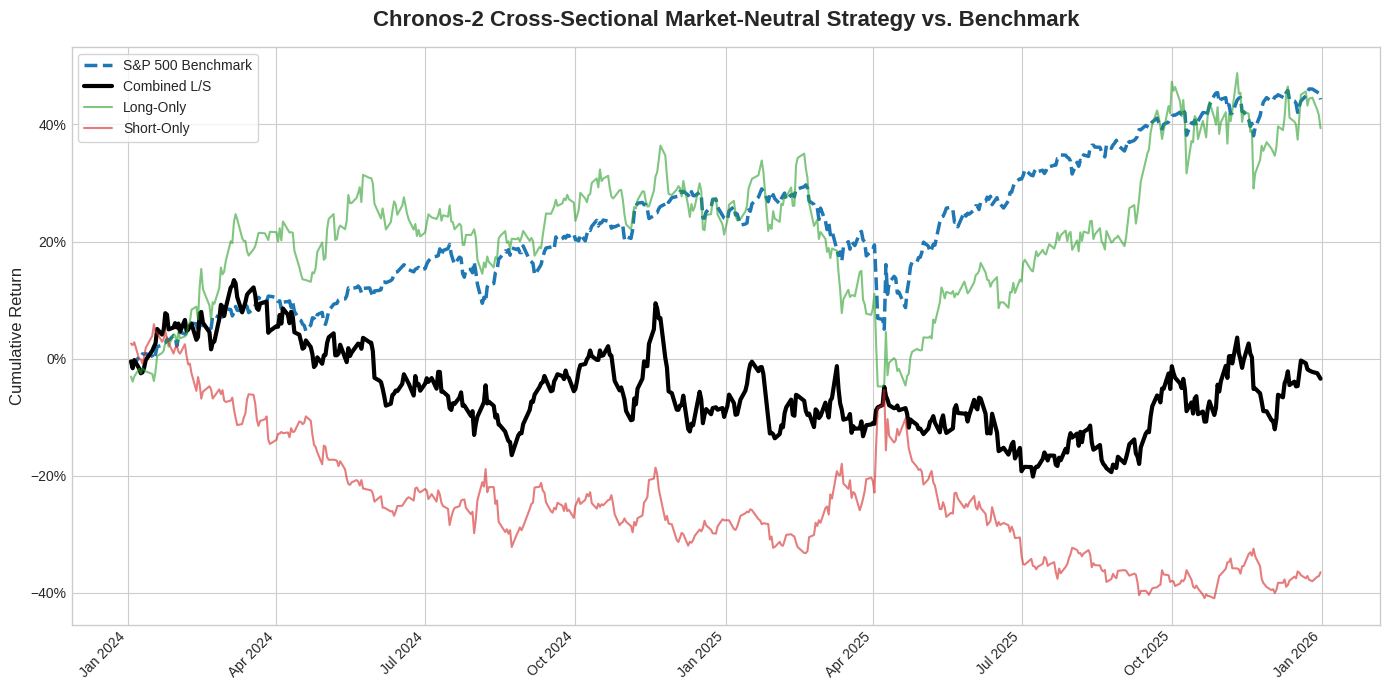

In [ ]:
def calc_financial_metrics(ret_series, rf=0.04):
    """
    Calculates institutional risk/return metrics for a given return series.

    Parameters
    ----------
    ret_series : pandas.Series
        The daily return series of the strategy or benchmark.
    rf : float, optional
        The assumed annualized risk-free rate (default is 0.04).

    Returns
    -------
    dict
        A dictionary containing formatted financial metrics (e.g., Sharpe, Sortino, Drawdown).
    """
    mean_ret = ret_series.mean()
    std_dev = ret_series.std()
    ann_ret = (1 + mean_ret)**252 - 1
    ann_std = std_dev * np.sqrt(252)
    ann_downside_std = ret_series[ret_series < 0].std() * np.sqrt(252)

    return {
        "Mean return (net)": f"{mean_ret*100:.4f}%",
        "Standard error": f"{ret_series.sem()*100:.4f}%",
        "t-Statistic": f"{mean_ret / ret_series.sem() if ret_series.sem() != 0 else 0:.2f}",
        "Minimum": f"{ret_series.min()*100:.2f}%",
        "Median": f"{ret_series.median()*100:.2f}%",
        "Maximum": f"{ret_series.max()*100:.2f}%",
        "Share > 0": f"{(ret_series > 0).mean()*100:.1f}%",
        "Standard dev.": f"{std_dev*100:.2f}%",
        "Skewness": f"{ret_series.skew():.2f}",
        "Kurtosis": f"{ret_series.kurtosis():.2f}",
        "Max. drawdown": f"{((1 + ret_series).cumprod() / (1 + ret_series).cumprod().cummax() - 1).min()*100:.2f}%",
        "Return p.a.": f"{ann_ret*100:.2f}%",
        "Standard dev. p.a.": f"{ann_std*100:.2f}%",
        "Sharpe ratio p.a.": f"{(ann_ret - rf) / ann_std if ann_std != 0 else 0:.2f}",
        "Sortino ratio p.a.": f"{(ann_ret - rf) / ann_downside_std if ann_downside_std != 0 else 0:.2f}"
    }

def evaluate_cross_sectional_strategy(results):
    """
    Prints metrics, plots the market-neutral portfolio, and exports results.

    Parameters
    ----------
    results : pandas.DataFrame
        The output DataFrame from the cross-sectional backtest containing strategy returns.

    Returns
    -------
    None
    """
    # Print Accuracy
    long_acc, short_acc = results['Long_Acc'].mean(), results['Short_Acc'].mean()
    print("\n=== CLASSIFICATION ACCURACY ===")
    print(f"Long-Only Leg Accuracy (Beat Median):   {long_acc*100:.2f}%")
    print(f"Short-Only Leg Accuracy (Under Median): {short_acc*100:.2f}%")
    print(f"Combined Classification Accuracy:       {((long_acc + short_acc)/2)*100:.2f}%")

    # Print Financial Table
    strat_metrics = calc_financial_metrics(results['Net_Strat'])
    spy_metrics = calc_financial_metrics(results['SPY_Return'])

    print("\n" + "="*70)
    print(f"{'FINANCIAL PERFORMANCE METRICS':^70}")
    print("="*70)
    print(f"{'Metric':<25} | {'Chronos L/S':<20} | {'S&P 500 (SPY)':<20}")
    print("-" * 70)

    print(f"{'Mean return (long-only leg)':<25} | {results['Long_Return'].mean()*100:<20.4f}% | {'N/A':<20}")
    print(f"{'Mean return (short-only leg)':<25} | {-results['Short_Return'].mean()*100:<20.4f}% | {'N/A':<20}")

    for key in strat_metrics.keys():
        if key in ["Minimum", "Standard dev.", "Max. drawdown", "Return p.a."]: print("-" * 70)
        print(f"{key:<25} | {strat_metrics[key]:<20} | {spy_metrics[key]:<20}")
    print("="*70 + "\n")

    # Plotting
    fig, ax = plt.subplots(figsize=(14, 7))
    fig.patch.set_alpha(0.0)
    ax.patch.set_alpha(0.0)

    cum_spy = (1 + results['SPY_Return']).cumprod() - 1
    cum_strat = (1 + results['Net_Strat']).cumprod() - 1
    cum_long = (1 + (results['Long_Return'] - (results['Turnover_Cost']/2))).cumprod() - 1
    cum_short_ret = (1 + (-results['Short_Return'] - (results['Turnover_Cost']/2))).cumprod() - 1

    ax.plot(results['Date'], cum_spy * 100, label='S&P 500 Benchmark', color='#1f77b4', linewidth=2.5, linestyle='--')
    ax.plot(results['Date'], cum_strat * 100, label='Combined L/S', color='black', linewidth=3)
    ax.plot(results['Date'], cum_long * 100, label='Long-Only', color='#2ca02c', alpha=0.6, linewidth=1.5)
    ax.plot(results['Date'], cum_short_ret * 100, label='Short-Only', color='#d62728', alpha=0.6, linewidth=1.5)

    ax.set_title('Chronos-2 Cross-Sectional Market-Neutral Strategy vs. Benchmark', fontsize=16, fontweight='bold', pad=15)
    ax.set_ylabel('Cumulative Return', fontsize=12)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.legend(loc='upper left', frameon=True)

    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    plt.tight_layout()

    # Export the accuracy metrics
    acc_df = pd.DataFrame({
        'Metric': ['Long-Only Leg Accuracy (Beat Median)', 'Short-Only Leg Accuracy (Under Median)', 'Combined Classification Accuracy'],
        'Value': [f"{long_acc*100:.2f}%", f"{short_acc*100:.2f}%", f"{((long_acc + short_acc)/2)*100:.2f}%"]
    })
    acc_df.to_csv('cross_sectional_accuracy_metrics.csv', index=False)

    # Export the full FK2017 financial table
    fin_metrics_df = pd.DataFrame({
        'Metric': list(strat_metrics.keys()),
        'Chronos L/S Neutral': list(strat_metrics.values()),
        'S&P 500 (SPY)': list(spy_metrics.values())
    })

    # Prepend the leg-specific returns to match the console output
    top_rows = pd.DataFrame({
        'Metric': ['Mean return (long-only leg)', 'Mean return (short-only leg)'],
        'Chronos L/S Neutral': [f"{results['Long_Return'].mean()*100:.4f}%", f"{-results['Short_Return'].mean()*100:.4f}%"],
        'S&P 500 (SPY)': ['N/A', 'N/A']
    })
    fin_metrics_df = pd.concat([top_rows, fin_metrics_df], ignore_index=True)
    fin_metrics_df.to_csv('cross_sectional_financial_metrics.csv', index=False)

    # Export Data & Graph
    results.to_csv('cross_sectional_market_neutral_results.csv', index=False)
    plt.savefig('cross_sectional_market_neutral_performance.png', transparent=True, dpi=300, bbox_inches='tight')
    print("Exported 'cross_sectional_market_neutral_results.csv' and 'cross_sectional_market_neutral_performance.png'")

    plt.show()

evaluate_cross_sectional_strategy(cross_sectional_results)